Example processed file: frame_0000.png
Original image shape: (480, 640)
Enhanced image shape: (480, 640)


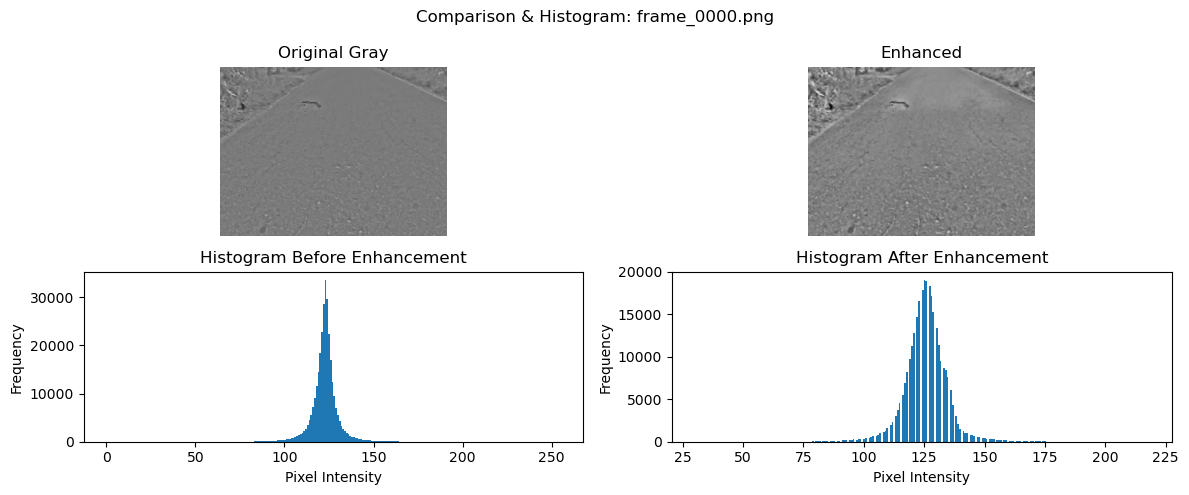

In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

input_folder = "shadow_removed"
output_folder = "enhanced_images"

os.makedirs(output_folder, exist_ok=True)

example_file = None
example_before = None
example_after = None

for filename in sorted(os.listdir(input_folder)):
    img_path = os.path.join(input_folder, filename)
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        continue

    clahe = cv2.createCLAHE(clipLimit=0.8, tileGridSize=(16,16))
    enhanced = clahe.apply(gray)
    enhanced = cv2.GaussianBlur(enhanced, (5,5), 1)
    smoothed = cv2.GaussianBlur(enhanced, (5,5), 0)
    enhanced = cv2.addWeighted(enhanced, 1.2, smoothed, -0.2, 0)

    cv2.imwrite(os.path.join(output_folder, filename), enhanced)

    if example_file is None:
        example_file = filename
        example_before = gray
        example_after = enhanced

if example_file:
    print("Example processed file:", example_file)
    print("Original image shape:", example_before.shape)
    print("Enhanced image shape:", example_after.shape)

    plt.figure(figsize=(12,5))

    plt.subplot(2,2,1)
    plt.imshow(example_before, cmap='gray')
    plt.title("Original Gray")
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.imshow(example_after, cmap='gray')
    plt.title("Enhanced")
    plt.axis('off')

    plt.subplot(2,2,3)
    plt.hist(example_before.ravel(), bins=256)
    plt.title("Histogram Before Enhancement")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.subplot(2,2,4)
    plt.hist(example_after.ravel(), bins=256)
    plt.title("Histogram After Enhancement")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.suptitle(f"Comparison & Histogram: {example_file}")
    plt.tight_layout()
    plt.show()
else:
    print("No valid images found.")